# [실습] LangChain을 이용한 오픈 RAG 만들기

RAG는 Retrieval-Augmented Generation (RAG) 의 약자로, 질문이 주어지면 관련 있는 문서를 찾아 프롬프트에 추가하는 방식의 어플리케이션입니다.   
RAG의 과정은 아래와 같이 진행됩니다.
1. Indexing : 문서를 받아 검색이 잘 되도록 저장합니다.
1. Processing : 입력 쿼리를 전처리하여 검색에 적절한 형태로 변환합니다<br>
1. Search(Retrieval) : 질문이 주어진 상황에서 가장 필요한 참고자료를 검색합니다.
1. Augmenting : Retrieval의 결과와 입력 프롬프트를 이용해 LLM에 전달할 프롬프트를 생성합니다.
1. Generation : LLM이 출력을 생성합니다.

## 라이브러리 설치  

랭체인 관련 라이브러리와 벡터 데이터베이스 라이브러리를 설치합니다.  
<br>
  
`langchain_chroma`: ChromaDB를 이용해 벡터 데이터베이스를 구성합니다.    

In [ ]:
# LangChain + LLM
!pip install langchain-huggingface langchain==0.3.27 langchain-openai langchain-community==0.3.27

  Using cached langchain_huggingface-0.3.1-py3-none-any.whl.metadata (996 bytes)


In [2]:
# RAG
!pip install langchain_chroma

In [ ]:
# 기타
!pip install dotenv jsonlines beautifulsoup4 matplotlib setuptools koreanize-matplotlib

  Using cached jsonlines-4.0.0-py3-none-any.whl.metadata (1.6 kB)


# env 파일 불러오기   

In [4]:
import openai
from dotenv import load_dotenv

load_dotenv('.env', override=True)

client = openai.OpenAI()
# API 키 검증하기
try: client.models.list(); print("OPENAI_API_KEY가 정상적으로 설정되어 있습니다.")
except:  print(f"OpenAI API 키가 유효하지 않습니다!")


OPENAI_API_KEY가 정상적으로 설정되어 있습니다.


## LLM과 임베딩 모델 구성하기     

In [5]:
from langchain_openai import ChatOpenAI

gpt5 = ChatOpenAI(model='gpt-5-mini',
                 temperature=1.0)

gpt41 = ChatOpenAI(model='gpt-4.1-mini',
                 temperature=0)

sllm = ChatOpenAI(model='gpt-3.5-turbo',
                 temperature=0)

test = '안녕!!!!! 너는 누구니?'
print('gpt5:', gpt5.invoke(test).content)
print('gpt41:', gpt41.invoke(test).content)
print('sllm:', sllm.invoke(test).content)

gpt5: 안녕! 반가워요 😄  
저는 OpenAI가 만든 AI 언어 모델 ChatGPT예요. 질문에 답하고, 글쓰기·번역·코딩·공부 도움·아이디어 제안 등 여러 가지를 도와줄 수 있어요. (참고: 제 지식은 2024년 6월까지이고, 실시간 인터넷 검색은 할 수 없어요.)

무엇을 도와줄까?
gpt41: 안녕!!! 나는 OpenAI가 만든 AI 언어 모델이야. 너랑 대화하고 궁금한 것 도와주려고 여기 있어! 뭐든지 물어봐도 돼~
sllm: 안녕하세요! 저는 인공지능 챗봇입니다. 무엇을 도와드릴까요?


## Embedding


RAG의 구조는 검색을 수행하기 위한 임베딩 모델이 필요합니다.   
임베딩 모델은 텍스트를 벡터로 변환하며,    
이후 결과를 벡터 DB에 저장해 검색할 수 있습니다.

OpenAI의 `text-embedding-3-large` 는 빠른 속도로 연산이 가능하나, 비용이 발생하며 온라인 모델입니다.   
이에 따라, 폐쇄망/온프레미스 환경에서는 공개 임베딩 모델을 사용하여 구현해야 합니다.

In [6]:
from langchain_openai import OpenAIEmbeddings
openai_embeddings = OpenAIEmbeddings(model='text-embedding-3-large', 
                                     chunk_size = 100)
# Embedding의 chunk_size : 동시 처리 요청 수 (청크 크기가 아님!!!!!)

오픈 임베딩 모델에서 중요한 파라미터는 다음과 같습니다.

- 파라미터 수 : 큰 임베딩 모델의 크기는 LLM에 육박합니다. GPU를 고려하여 선택합니다.
- Max Tokens: 임베딩 모델의 최대 토큰보다 큰 데이터를 입력하면, 앞부분만을 이용해 계산하게 되므로 적절한 검색이 되지 않을 수 있습니다.
- 임베딩 차원: 큰 차원의 벡터를 생성하는 임베딩 모델은 검색 속도가 감소합니다.

현재 한국어 데이터를 임베딩하기 위해 자주 사용하는 모델은 아래와 같습니다.

- BAAI/BGE-M3 (2GB, 8194 토큰 제한)   
BGE-M3 시리즈는 BAAI의 임베딩 모델로, 현재 가장 인기가 많은 모델입니다.

- nlpai-lab/KURE-v1 (2GB, 8194 토큰 제한)    
KURE 임베딩은 고려대학교 NLP 연구실에서 만든 모델로, BGE-M3를 한국어 텍스트로 파인 튜닝한 모델입니다.

- Qwen/Qwen-3-Embedding (0.6B, 4B, 8B, 32768 토큰 제한)    
알리바바 클라우드의 Qwen 모델을 개량하여 만든 모델입니다.    
가장 최신 모델로, BGE-M3와의 성능 비교가 치열합니다.

RAG를 하기 전, 비교를 위해 LLM에게 질문해 보겠습니다.

In [7]:
# Test
for s in gpt5.stream("도메인 특화 언어 모델이란 무엇입니까? 어떤 예시가 있나요?"):
    print(s.content, end='')

print('\n--------\n')
for s in gpt41.stream("도메인 특화 언어 모델이란 무엇입니까? 어떤 예시가 있나요?"):
    print(s.content, end='')

print('\n--------\n')
for s in sllm.stream("도메인 특화 언어 모델이란 무엇입니까? 어떤 예시가 있나요?"):
    print(s.content, end='')

도메인 특화 언어 모델(도메인 특화 LLM / DSLM)은 일반 목적의 언어 모델(예: GPT, LLaMA 등)을 특정 분야(의료·법률·금융·과학·코드 등)의 언어·지식·용어·문체에 맞게 조정하거나, 해당 분야의 대규모 코퍼스로 처음부터 학습시켜 만든 모델입니다. 목적은 그 분야 고유의 전문용어, 사실관계, 규칙, 형식적 표현 등을 더 정확하고 신뢰성 있게 다루는 것입니다.

주요 특징 — 일반 모델과의 차이
- 전문 용어·문장 구조와 도메인 지식에 더 최적화됨
- 해당 분야의 자료(논문, 진료기록, 판례, 재무보고서 등)를 잘 이해하고 생성
- 안전성·규정 준수가 중요한 분야(의료·금융·법률)에서 맞춤 규칙 적용 가능
- 단점: 범용성 감소, 데이터 편향 위험, 구축·유지 비용 발생

대표적 예시(도메인별)
- 의료/생명과학
  - BioBERT, PubMedBERT, ClinicalBERT: 바이오·임상 텍스트에 특화된 BERT 계열 모델
  - Med-PaLM: 구글의 의료 분야 대형 언어 모델 연구
- 과학·학술
  - SciBERT: 과학 논문 텍스트에 특화
  - Galactica(논쟁 있었음): 과학 지식을 다루는 시도
- 법률
  - LegalBERT 등: 판례·법령 텍스트에 특화된 모델, 법률 문서 검색·분석에 사용
- 금융
  - FinBERT, BloombergGPT: 재무·뉴스·리포트에 맞춘 모델(특히 BloombergGPT는 금융 특화 대형 모델)
- 코드·프로그래밍
  - Codex(OpenAI), CodeBERT, StarCoder, CodeGen: 코드 생성·보완·분석에 특화
- 화학·약물 설계
  - ChemBERTa, SMILES 기반 모델: 화학식·분자표현에 특화
- 기업 내부(엔터프라이즈)
  - RAG(검색기반 생성)+사내 문서로 파인튜닝한 모델: 고객지원, 내부 검색·요약, 계약서 자동화 등

만드는 방법(흔한 접근)
- Continued Pretraining(도메인 연속 사전학습): 일반 모델을 도메인 코퍼스로 추가 학

## 데이터 준비하기    
이번 실습에서는 삼성SDS의 기술 블로그 HTML 데이터를 불러와 활용해 보겠습니다.


In [8]:
import requests
import os

sds_urls = [
    'https://www.samsungsds.com/kr/research-blog/agentic-ai-emergence-attention.html',
    'https://www.samsungsds.com/kr/research-blog/sky-computing-future-samsungsds.html',
    'https://www.samsungsds.com/kr/research-blog/samsung-sds-research-director-interview.html',
    'https://www.samsungsds.com/kr/research-blog/samsung-sds-ai-research-team-agentic-ai-interview.html',
    'https://www.samsungsds.com/kr/research-blog/agentic-ai-sds-keynote.html',
    'https://www.samsungsds.com/kr/research-blog/post-quantum-crypto-migration.html',
    'https://www.samsungsds.com/kr/research-blog/ai-preference-consistency.html',
    'https://www.samsungsds.com/kr/research-blog/pim-inference-acceleration.html',
    'https://www.samsungsds.com/kr/insights/agentic-ai-in-mobile-and-field-operations.html',
    'https://www.samsungsds.com/kr/insights/vertical-ai-agents-part1.html',
    'https://www.samsungsds.com/kr/insights/how-to-build-agentic-ai.html',
    'https://www.samsungsds.com/kr/insights/ai-risk-management-framework.html',
    'https://www.samsungsds.com/kr/insights/deepseek-to-change-the-ai-product-market.html',
    'https://www.samsungsds.com/kr/insights/business-potential-in-small-language-models.html',
    'https://www.samsungsds.com/kr/insights/ondevice-ai-and-cloud-ai.html',
]

## LangChain Document Loaders

LangChain의 `document_loaders`는 다양한 형식의 파일을 불러올 수 있습니다.   
[https://python.langchain.com/docs/integrations/document_loaders/ ]    

Web URL로부터 페이지를 로드하는 기본 파서인 `WebBaseLoader`를 사용합니다.   

In [9]:
# Jupyter 분산 처리를 위한 설정
import nest_asyncio

nest_asyncio.apply()

In [13]:
import bs4
from langchain_community.document_loaders import WebBaseLoader

async def get_news_documents(links):
    loader = WebBaseLoader(
        web_paths=links,
        requests_per_second = 10, # 1초에 10개 요청 보내기
        show_progress = True # 진행 상황 출력
    )
    # docs = loader.load() # 기본 코드
    # return docs

    docs = []

    async for doc in loader.alazy_load():
        # 순차적 로드 대신 비동기 처리
        docs.append(doc)
    return docs

docs = await get_news_documents(sds_urls)

Fetching pages: 100%|##########| 15/15 [00:00<00:00, 84.73it/s]


In [16]:
for doc in docs:
    print(doc.page_content[1000:1050])
    print(len(doc.page_content))

니다. 어텐션은 입력 단어의 모든 가능한 쌍에 대해 상관관계를 계산하는 메커니즘 입니다. 
4122
인 인프라 영역
이러한 복잡성을 해소하기 위해 UC 버클리대 Sky Computing La
5569
핵심 기술 분야에서 경쟁력을 확보하고 있는 삼성SDS 연구소의 성과와 삼성SDS가 그리는 
12825
I 연구팀이 만들어나갈 미래를 소개합니다.

"저에게 컴퓨터는 문제를 푸는 놀이였습니다"

11500
화하고 있는지 발표하였습니다. 또, 의사결정/예측 Agent와 상담요약/답변추천 Agent
2194
 공개키 암호를 PQC로 전환해야 하는 시점에 도달했습니다. 특히 가트너는 2025년 
 
4684
ing, IFT) 보다 더 나은 선호 정렬을 달성할 수 있도록 합니다.  
    그러나,
5072
의 벡터가 만들어지고, 그중 Key와 Value는 계속해서 저장되고 불러와야 합니다. 한 
3547
미션 크리티컬한 워크플로우는 AI가 가장 큰 비즈니스 가치를 발휘할 수 있는 영역입니다. 
8224
적용될 전망입니다. [1]

    많은 기업들이 이러한 AI 에이전트를 도입하고, 단순 
18565
준에 머무르고 있으며, 어떤 기업은 복잡한 업무 프로세스 전반에 걸쳐 다수의 에이전트를 어
9698
며, 승인된 AI 옵션을 제공하면서도 섀도우 AI의 데이터 위험을 통제하지 못하는 실정입니
6076
건설은행(CCB)은 내부 금융 모델 개발에 딥시크 R1을 도입했고, 온라인 증권사인 타이거
13865
로드(Claude), 그록(Grok) 등 기능이 다양한 범용 LLM이 주목받고 있지만, 메
4358
버 모델 역시 발전했다. PC 시대에도 기업들은 데이터베이스 서버를 두고 클라이언트 PC에
11055


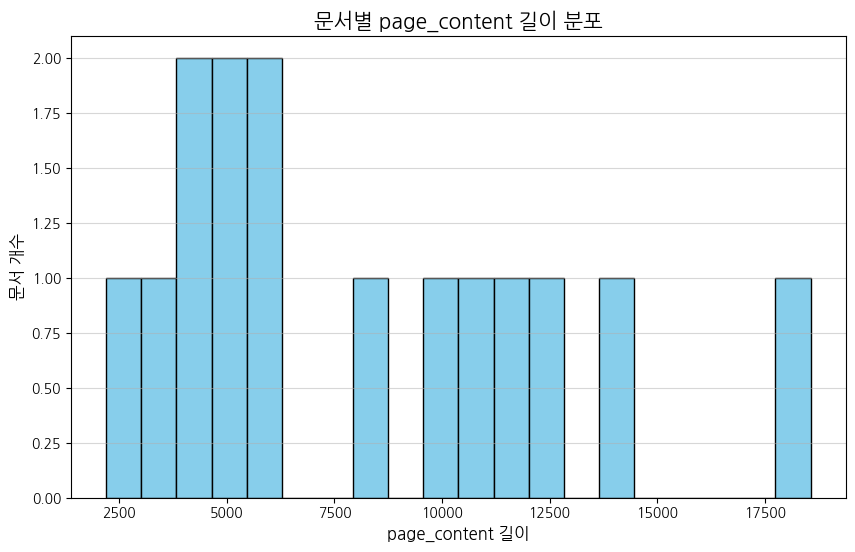

In [17]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

document_lengths = [len(document.page_content) for document in docs]

# 히스토그램 그리기
plt.figure(figsize=(10,6))
plt.hist(document_lengths, bins=20, color='skyblue', edgecolor='black')
plt.title('문서별 page_content 길이 분포', fontsize=15)
plt.xlabel('page_content 길이', fontsize=12)
plt.ylabel('문서 개수', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()


In [18]:
docs[0]

Document(metadata={'source': 'https://www.samsungsds.com/kr/research-blog/agentic-ai-emergence-attention.html', 'title': 'AI의 새로운 지평: 어텐션, 창발, 그리고 Agentic AI – 한국정보처리학회 2025년 IT21 글로벌 컨퍼런스 키노트 스피치 리뷰 | 기술블로그 | 리서치 | 삼성SDS', 'description': '어텐션과 창발 개념을 통해 바라본 Agentic AI의 미래와 삼성SDS의 인사이트를 전합니다.', 'language': 'ko'}, page_content='\ufeff\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nAI의 새로운 지평: 어텐션, 창발, 그리고 Agentic AI – 한국정보처리학회 2025년 IT21 글로벌 컨퍼런스 키노트 스피치 리뷰 | 기술블로그 | 리서치 | 삼성SDS\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n \n\n\n\n\n\n\n\n\n\n\n\n\n\n \n\n\n\n\n\n\n\n본문 바로 가기\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n연구소 소식\nAI의 새로운 지평: 어텐션, 창발, 그리고 Agentic AI – 한국정보처리학회 2025년 IT21 글로벌 컨퍼런스 키노트 스피치 리뷰\n\n2025-07-21삼성SDS\n\n\n\n\n\n\n\n\n\n\n        삼성SDS 권영준 연구소장은 ‘어텐션부터 언어모델로 Agentic AI까지’의 제목으로 한국정보처리학회의 2025년 IT21 글로벌 컨퍼런스에서 키노트 스피치를 하였습니다.\n        \n        혹시 여러분은 ‘창발(Emergence)’이라는 단어를 들어보신 적이 있으신가요? 이번 키노트 스피치에서 권영준 연구소장은 AI기술의 흐름에서 ‘창발’이 어떤 영향을 끼쳤는지는 설명하고, 약 40년 전에 쓰여진 책에 이미 에이전트의 개념

불필요한 내용을 전처리합니다.  

'본문 바로 가기', '\n공유하기\n', '\n인쇄하기\n' '\nloading...\n' 등의 단어를 제거하고,    
중복된 줄바꿈 기호도 하나로 연결하겠습니다.


In [19]:
docs[-1].page_content

'\ufeff\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n클라우드 AI vs 온디바이스 AI: 공존과 진화의 방향 | 인사이트리포트 | 삼성SDS\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n \n\n\n\n\n\n\n\n본문 바로 가기\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n인사이트 리포트/상세 기사\n\n\n\n\n\n\nloading...\n\n\n\n\n\n\n\n인공지능\n클라우드 AI vs 온디바이스 AI: 공존과 진화의 방향\n\n2025-04-16\n김지현\n\n\n\n\n\n\n\n\n공유하기\n\n\n\n\n인쇄하기\n\n\n\n\n\n\n\n\n\n최근 인공지능 활용 방식은 두 갈래로 나뉜다. 하나는 거대한 파운데이션 모델(FM, Foundation Model)로, 클라우드의 방대한 데이터센터에서 동작하는 AI다. 다른 하나는 스몰 랭귀지 모델(SLM, Small Language Model)처럼 스마트폰이나 PC 등 디바이스 내에서 직접 실행되는 AI다. 이러한 구조는 IT 역사에서 서버와 클라이언트가 공생하며 발전해 온 흐름과 일맥상통한다. 중앙집중형과 분산형 컴퓨팅의 변천사를 배경으로 클라우드 속 AI와 온디바이스 AI의 장단점을 살펴보고, 두 방식의 공존이 만들어갈 미래를 분석한다.\n서버와 클라이언트의 공생 속에 발전한 컴퓨터\n\n\t초기의 컴퓨팅 환경은 중앙집중형이었다. 1960~70년대에는 거대한 메인프레임 서버 한 대에 여러 사용자가 단말기를 통해 접속하는 구조로 모든 연산이 서버에서 이루어졌고, 클라이언트 단말은 입출력만 담당했다. 이후 1980년대부터 본격적으로 개인용 컴퓨터(PC)의 등장하면서 컴퓨팅 권한이 클라이언트로 분산되기 시작했다. 1990년대부터 본격적으로 PC 보급이 늘면서 사람들은 각자 컴퓨터를 소유하게 되었고, 중앙 메인프레임 위주의 계산 작업이 개인 기기로 분산되었다. 

In [20]:
import re

def preprocess(docs):
    noise_texts = [
        '본문 바로 가기',
        '\n공유하기\n',
        '\n인쇄하기\n',
        '\nloading...\n',
        '\ufeff',
    ]

    def clean_text(doc):
        text = doc.page_content
        # 노이즈 텍스트 제거
        for noise in noise_texts:
            text = text.replace(noise, '')

        # 탭과 개행문자를 공백으로 변환
        text = text.replace('\t', ' ').replace('\n', ' ')

        # 연속된 공백을 하나로 치환
        text = re.sub(r'\s+', ' ', text).strip()

        doc.page_content = text

        return doc


    preprocessed_docs = []
    for doc in docs:

        # 텍스트 정제
        doc= clean_text(doc)
        preprocessed_docs.append(doc)

    return preprocessed_docs

preprocessed_docs = preprocess(docs)


In [21]:
preprocessed_docs[-1].page_content

'클라우드 AI vs 온디바이스 AI: 공존과 진화의 방향 | 인사이트리포트 | 삼성SDS 인사이트 리포트/상세 기사 인공지능 클라우드 AI vs 온디바이스 AI: 공존과 진화의 방향 2025-04-16 김지현 최근 인공지능 활용 방식은 두 갈래로 나뉜다. 하나는 거대한 파운데이션 모델(FM, Foundation Model)로, 클라우드의 방대한 데이터센터에서 동작하는 AI다. 다른 하나는 스몰 랭귀지 모델(SLM, Small Language Model)처럼 스마트폰이나 PC 등 디바이스 내에서 직접 실행되는 AI다. 이러한 구조는 IT 역사에서 서버와 클라이언트가 공생하며 발전해 온 흐름과 일맥상통한다. 중앙집중형과 분산형 컴퓨팅의 변천사를 배경으로 클라우드 속 AI와 온디바이스 AI의 장단점을 살펴보고, 두 방식의 공존이 만들어갈 미래를 분석한다. 서버와 클라이언트의 공생 속에 발전한 컴퓨터 초기의 컴퓨팅 환경은 중앙집중형이었다. 1960~70년대에는 거대한 메인프레임 서버 한 대에 여러 사용자가 단말기를 통해 접속하는 구조로 모든 연산이 서버에서 이루어졌고, 클라이언트 단말은 입출력만 담당했다. 이후 1980년대부터 본격적으로 개인용 컴퓨터(PC)의 등장하면서 컴퓨팅 권한이 클라이언트로 분산되기 시작했다. 1990년대부터 본격적으로 PC 보급이 늘면서 사람들은 각자 컴퓨터를 소유하게 되었고, 중앙 메인프레임 위주의 계산 작업이 개인 기기로 분산되었다. 예를 들어 예전에는 은행 업무를 한 메인프레임이 도맡았다면, PC 시대에는 가정이나 사무실에서 스프레드시트를 이용해 간단한 회계 작업을 수행할 수 있게 된 것이다. (출처: 구글 제미나이 Imagen 3로 생성) 하지만 클라이언트↔서버 모델 역시 발전했다. PC 시대에도 기업들은 데이터베이스 서버를 두고 클라이언트 PC에서 데이터를 요청하는 클라이언트↔서버 구조를 활용했다. 1990년대 인터넷이 보급되면서 웹 서버와 브라우저 간의 새로운 클라이언트↔서버 관계가 탄생했고, 애플리케이션은 다계층 구조로 분리되어

불러온 텍스트 데이터는 파일로 저장할 수 있습니다.

In [22]:
# 불러온 document 저장하기
import jsonlines
def save_docs_to_jsonl(documents, file_path):
    with jsonlines.open(file_path, mode="w") as writer:
        for doc in documents:
            writer.write(doc.model_dump())
save_docs_to_jsonl(preprocessed_docs, "docs.jsonl")

# jsonl 파일 불러오기
from langchain.schema import Document

def load_docs_from_jsonl(file_path):
    documents = []
    with jsonlines.open(file_path, mode="r") as reader:
        for doc in reader:
            documents.append(Document(**doc))
    return documents


## Chunking: 청크 단위로 나누기   



전처리가 완료된 docs를 chunk 단위로 분리합니다.
`chunk_size`와 `chunk_overlap`을 이용해 청크의 구성 방식을 조절할 수 있습니다.  

Chunk Size * K(검색할 청크의 수) 의 결과가 Context의 길이가 됩니다.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
# 0~1000, 800~1800, 1600~2600, 2400~3400, ...
# 구분자 기준 청킹
chunks = text_splitter.split_documents(preprocessed_docs)
print(len(chunks))

143


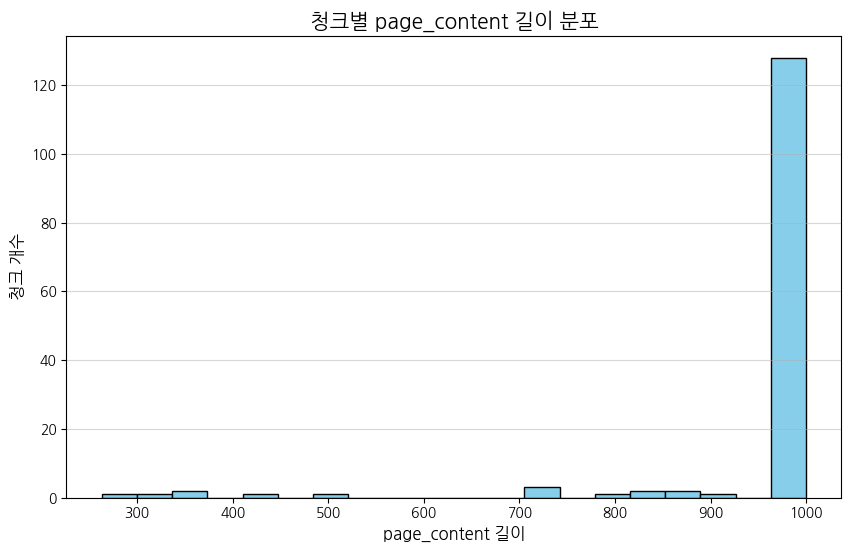

In [68]:
chunk_lengths = [len(chunk.page_content) for chunk in chunks]

# 히스토그램 그리기
plt.figure(figsize=(10,6))
plt.hist(chunk_lengths, bins=20, color='skyblue', edgecolor='black')
plt.title('청크별 page_content 길이 분포', fontsize=15)
plt.xlabel('page_content 길이', fontsize=12)
plt.ylabel('청크 개수', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()


## Vector Database 만들기   

구성된 청크를 벡터 데이터베이스에 로드합니다.   

In [69]:
from langchain_chroma import Chroma
import uuid

Chroma().delete_collection() # (메모리에 저장하는 경우) 기존 데이터 삭제

uuidstr = str(uuid.uuid4())[0:6]
# 랜덤 문자열

# DB 구성하기
db = Chroma(embedding_function=openai_embeddings,
            persist_directory=f"./chroma_OpenAI_{uuidstr}",
            # 파일 시스템에 저장 (생략시 메모리에 저장)

            collection_name='Web', # 식별 이름

            collection_metadata={'hnsw:space':'l2'},
            # l2 메트릭 설정(기본값, cosine, mmr 로 변경 가능)
            )

DB에 document를 추가합니다.    
OpenAI 임베딩은 30만 토큰 동시 처리 제한이 있어, 나눠서 전달합니다.

In [70]:
from tqdm import tqdm

# 임베딩의 chunk_size 를 정해서 전달
# 오픈 모델의 경우, 직접 배치로 처리

db.add_documents(chunks)

['73708b41-060b-4b41-83bf-db04c10614a5',
 '86c4c8a1-4e30-4a3b-80ec-a836340e9dab',
 '393be453-0ab4-4464-aa0a-e9691da79695',
 '21228c88-33fb-43bd-a267-644db3a784c2',
 'b78737b6-eab7-45e1-87ae-27ba5273b7d5',
 'd1d8b803-cff2-44e4-9aef-72f6a334d1c1',
 '845b1074-38ff-47e9-a88e-b679193e018c',
 '323caf42-bedd-47bc-b676-81876df0922a',
 '5efc8156-a92e-46b4-b22f-4ff3baecf669',
 'c12618ca-f992-4840-82f2-c977c8db481c',
 '83f290b3-2d65-49bc-b6f7-694541a55508',
 '65e7447f-1f72-4613-84e1-3617baf5a023',
 '79f3100e-e619-4234-b3e5-bbc3bbdbd500',
 'dd6abee9-f373-4572-becc-ea1c02256af9',
 'a4b836de-1874-4d43-a761-34d05e460ffa',
 'dc278e5a-8801-4027-bddf-185bec03158f',
 'a5c9155c-a325-4002-a53e-4fee62316e3c',
 '5278b85b-9bef-454a-9e8f-97908a31d006',
 'e218b98a-2969-4778-b866-631bac053044',
 'eac3b349-10c6-4c43-9801-9de3c561e784',
 'f63a516e-4140-4443-98e3-2b9f914bbe00',
 'f2f65a08-2ea8-4a53-bd36-2834f8d30455',
 'c751b4da-c11a-4ccb-b65d-b4635602860f',
 '6032f54e-0342-439e-a504-a8adc94ec82e',
 '410c5223-823b-

db로부터 retriever를 구성합니다.

In [71]:
# Top 5 Search(기본값은 4)
retriever = db.as_retriever(search_kwargs={'k':10})

In [72]:
result = retriever.invoke("도메인 특화 언어 모델")
for doc in result:
    print(doc.page_content[0:300])
    print('-------')


SLM 소규모언어모델 속 비즈니스 잠재력 | 인사이트리포트 | 삼성SDS 인사이트 리포트/상세 기사 인공지능 SLM(소규모언어모델) 속 비즈니스 잠재력 2025-05-12 Paula Rooney 이 글은 IDG의 아티클을 전재하여 제공합니다. [원문보기] 소규모 언어 모델(SLM)은 IT 리더가 기존 범용 LLM보다 적은 운영 비용으로 특정 비즈니스에 특화된 AI 애플리케이션을 개발할 기회를 제공하고 있습니다. 가트너(Gartner)는 최근 보고서에서, 2027년까지 특정 맥락에 맞게 설계된 소규모 모델의 사용량이 대규모 모델보다 
-------
클로드(Claude), 그록(Grok) 등 기능이 다양한 범용 LLM이 주목받고 있지만, 메타(Meta)의 라마 3.1(Llama 3.1), 마이크로소프트(Microsoft)의 파이(Phi), 구글(Google)의 젬마(Gemma) SLM 등 소규모 모델도 특정 업무를 위한 비용 효율적인 대안으로 점점 더 많이 등장하고 있습니다. 예를 들어 구글은 최근 출시한 젬마3 SLM이 엔비디아(Nvidia) GPU 한 대만으로 구동 가능하다고 밝혔습니다. SLM에 주목하는 기업들 에이버리 데니슨(Avery Dennison)의 CIO 니콜라스
-------
소규모 언어 모델은 보안, 거버넌스, 비용 문제를 상당 부분 해결할 수 있다.”고 했습니다. 구글 파트너이자 전문 버티컬 AI 솔루션을 개발 및 배포하는 인텔라젠(Intelagen)의 설립자이자 전 CIO인 톰 리처는 가트너 보고서가 현장의 흐름과 일치한다고 했습니다. 범용 LLM의 역할이 분명하지만, 특정 비즈니스 문제에는 더 작고 미세조정된 모델이 특히 규제가 엄격한 산업에서 효율성과 성과 모두에서 더 나은 결과를 제공합니다. SLM으로의 전환을 이끄는 주요 요인은 LLM의 환각 리스크입니다. 범용 LLM이 특정하거나 복잡한 비
-------
AI가 이상한 말을 하는 이유, 바로 선호 불일치 때문입니다– 언어모델 학습 품질을 높이는 셀프 큐레이션(Self-Curation)

## Prompting

RAG를 위한 간단한 프롬프트를 작성합니다.

In [73]:
from langchain.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate([
    ("system", '''당신은 QA(Question-Answering)을 수행하는 Assistant입니다.
다음의 Context를 이용하여 Question에 답변하세요.
정확한 답변을 제공하세요.
만약 모든 Context를 다 확인해도 정보가 없다면,
"정보가 부족하여 답변할 수 없습니다."를 출력하세요.'''),
('human', '''Context: {context}
---
Question: {question}''')])
prompt.pretty_print()

================================ System Message ================================

당신은 QA(Question-Answering)을 수행하는 Assistant입니다.
다음의 Context를 이용하여 Question에 답변하세요.
정확한 답변을 제공하세요.
만약 모든 Context를 다 확인해도 정보가 없다면,
"정보가 부족하여 답변할 수 없습니다."를 출력하세요.

================================ Human Message =================================

Context: {context}
---
Question: {question}


## Chain

RAG를 수행하기 위한 Chain을 만듭니다.

RAG Chain은 프롬프트에 context와 question을 전달해야 합니다.    
체인의 입력은 Question만 들어가므로, Context를 동시에 prompt에 넣기 위해서는 아래의 구성이 필요합니다.

In [74]:
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser

# retriever의 결과물은 List[Document] 이므로 이를 ---로 구분하는 함수
# metadata의 source를 보존하여 추가
def format_docs(docs):
    return " \n---\n".join(
        [f'Title: {doc.metadata['title']} \nURL: {doc.metadata["source"]} \nContent: {doc.page_content}\n' for doc in docs]
    )
    # result=''
    # for doc in docs:
    #     context = f'Content: {doc.page_content}\nURL:{doc.metadata["source"]}' + ' \n---\n '
    #     result += context
    # return result



    # join : 구분자를 기준으로 스트링 리스트를 하나의 스트링으로 연결

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    # retriever : question을 받아서 context 검색: document 반환
    # format_docs : document 형태를 받아서 텍스트로 변환
    # RunnablePassthrough(): 체인의 입력을 그대로 저장
    | prompt
    | gpt5
    | StrOutputParser()
)

In [53]:
print(format_docs(retriever.invoke("sLLM이 뭐야?")))

Title: SLM 소규모언어모델  속 비즈니스 잠재력 | 인사이트리포트 | 삼성SDS 
URL: https://www.samsungsds.com/kr/insights/business-potential-in-small-language-models.html 
Content: SLM 소규모언어모델 속 비즈니스 잠재력 | 인사이트리포트 | 삼성SDS 인사이트 리포트/상세 기사 인공지능 SLM(소규모언어모델) 속 비즈니스 잠재력 2025-05-12 Paula Rooney 이 글은 IDG의 아티클을 전재하여 제공합니다. [원문보기] 소규모 언어 모델(SLM)은 IT 리더가 기존 범용 LLM보다 적은 운영 비용으로 특정 비즈니스에 특화된 AI 애플리케이션을 개발할 기회를 제공하고 있습니다. 가트너(Gartner)는 최근 보고서에서, 2027년까지 특정 맥락에 맞게 설계된 소규모 모델의 사용량이 대규모 모델보다 최소 3배 이상 많아질 것으로 예상했습니다. 또한 LLM이 특정 비즈니스 맥락이 요구되는 업무에서 응답 정확도가 떨어진다는 것을 지적했습니다. 해당 보고서 작성에 참여한 가트너 애널리스트 수밋 아가왈은 “비즈니스 워크플로우에서 다양한 작업과 더 높은 정확성이 요구되면서 특정 기능이나 도메인 데이터에 맞게 미세조정된 특화 모델로의 전환이 가속화되고 있다. 소규모, 업무 특화 모델은 더 빠른 응답을 제공하고, 연산 리소스 소모가 적어 운영 및 유지보수 비용을 줄일 수 있다”고 분석했습니다. 인도 위프로(Wipro)의 기술 담당자인 매게쉬 카스투리 박사는 LLM이 SLM보다 오류가 더 많다고 생각하지 않지만, LLM의 환각(hallucination) 현상은 우려할 만하다고 언급했습니다. 은행이나 에너지 등 특정 산업 분야의 솔루션에는 SLM이 민첩성, 비용 효율성, 빠른 프로토타입 및 개발, 조직 데이터의 보안과 프라이버시 측면에서 더 적절할 수 있습니다. 오픈AI(OpenAI), 제미나이(Gemini), 클로드(Claude), 그록(Grok) 등 기능이 다양한 범용 L

In [55]:
rag_chain.invoke("도메인 특화 언어 모델이란 무엇입니까? 어떤 예시가 있나요?")

'도메인 특화 언어 모델(도메인 특화 SLM)은 특정 산업(예: 금융, 의료, 항공)이나 업무(고객응대, 감정분석, 시장동향 분석 등)에 맞게 사전학습·미세조정된 소규모 언어 모델을 말합니다. 범용 LLM 대비 특정 맥락에서 정확도가 높고 연산비용·응답지연이 적으며, 민감한 조직 데이터에 대해 보안·거버넌스 측면에서 유리한 것이 특징입니다. 또한 환각(hallucination) 리스크를 줄이는 데 유리해 규제가 엄격한 분야에서 선호됩니다.\n\n문맥에 나온 구체적 예시\n- 메타(Meta)의 Llama 3.1 (소규모/특화 모델로 언급)\n- 마이크로소프트(Microsoft)의 Phi(파이) SLM 포트폴리오 — 산업별 미세조정 모델 개발(바이엘, 로크웰 오토메이션, 지멘스 등과 협력)\n- 구글(Google)의 Gemma(젬마) / Gemma3 SLM — Gemma3는 엔비디아 GPU 한 대로 구동 가능하다고 발표됨\n\n대조적 사례(범용 LLM)\n- OpenAI, Google Gemini, Anthropic Claude, Grok 등은 범용 LLM으로 주로 언급됨.\n\n주요 활용 사례(문맥 기반)\n- 고객 서비스 자동화, 시장 동향 분석, 제품 혁신, 감정 분석, 의료·금융·에너지 등 규제 분야 업무 최적화 등.'

In [56]:
rag_chain.invoke("인공지능의 최근 발전 방식은? 관련 링크도 보여주세요")

'최근 인공지능의 발전 방식(요약)\n- 어텐션 메커니즘: 입력 단어 쌍 간 상관관계를 계산하는 어텐션으로 LLM 계열의 언어모델이 가능해짐.  \n- 스케일링과 창발(Emergence): 파라미터·데이터·컴퓨팅 확대로 예측 불가능한 능력(추론·코딩·수학 등)이 나타나며 패러다임 전환을 촉발.  \n- 에이전틱(Agentic) AI 및 멀티에이전트: LLM을 에이전트화해 의사결정·툴 사용·멀티모달 처리 등을 수행하고, 여러 에이전트 협업으로 추론 향상.  \n- 멀티모달 인터페이스: 텍스트뿐 아니라 음성·이미지·영상 등 복합 입력을 처리하는 대화형 인터페이스로 전환.  \n- 클라우드 AI ↔ 온디바이스 AI의 공존(하이브리드): 대형 파운데이션 모델(FM)은 클라우드, 실시간·사소한 반응은 디바이스의 SLM이 담당하며 연합학습 등으로 개인 데이터 유출을 줄이고 협력적 개선을 추구.  \n- 비즈니스·제품 전략 변화: 오픈소스·경량 모델 확산, 프리미엄 서비스화, 산업별(버티컬) 특화 AI 에이전트의 등장.\n\n관련 기사(원문 링크)\n- AI의 새로운 지평: 어텐션, 창발, 그리고 Agentic AI – 키노트 스피치 리뷰  \n  https://www.samsungsds.com/kr/research-blog/agentic-ai-emergence-attention.html\n- 클라우드 AI vs 온디바이스 AI: 공존과 진화의 방향  \n  https://www.samsungsds.com/kr/insights/ondevice-ai-and-cloud-ai.html\n- 버티컬 AI 에이전트, 산업을 혁신하는 특화 AI 시대 (1)  \n  https://www.samsungsds.com/kr/insights/vertical-ai-agents-part1.html\n- 딥시크 DeepSeek 가 가져온 AI 프로덕트 시장의 변화  \n  https://www.samsungsds.com/kr/insights/deepseek-to-change-the-ai-prod

In [57]:
rag_chain.invoke("멀티모달 모델은 어떻게 발전할까요?")

'Context에 근거하면 멀티모달 모델의 발전 방향은 다음과 같이 정리할 수 있습니다.\n\n- 여러 형태의 데이터를 동시에 처리·통합하는 능력 강화  \n  - 텍스트·이미지·음성·센서(레이더·라이다 등)·로그·의료영상 등 다양한 입력을 한 모델에서 통합 분석해 복합적 맥락을 이해하고 의사결정을 지원한다(예: 자율주행, 의료 진단, 고객 상담).  \n\n- 에이전트형 멀티모달 아키텍처 채택  \n  - Multi-modal Agent 구조(사용자 질문 → 멀티모달 에이전트 ←→ 에이전트 메모리/파운데이션 모델 ←→ 에이전트 도구(텍스트 처리·오디오·비주얼·검색 등) ←→ 멀티모달 데이터 저장소)를 통해 실무에 맞는 상호작용과 문제해결을 제공한다.  \n\n- 파운데이션 모델 + 특화(소형) 모델의 조합 확대  \n  - 대규모 모델은 기반 역량을 제공하고, 비즈니스 목적에 맞게 경량화·미세조정된 소형 특화 모델(SLM)들이 구체적 요구를 충족하도록 활용된다.  \n\n- 온디바이스 운용을 위한 경량화·최적화 기술 발전  \n  - 양자화, 지식 증류, 구조 최적화 등으로 모델 크기·연산 요구를 낮춰 일부 멀티모달 기능을 기기에서도 제공하려는 시도가 지속된다(프라이버시·속도 이점).  \n\n- 분산·멀티 에이전트 시스템과의 결합  \n  - 중앙집중형·분산형 멀티에이전트 구조를 통해 에이전트 간 정보 공유·협력을 통해 확장성·적응성·정확성을 높이는 방향으로 발전한다.  \n\n- 인간의 다감각적 판단을 모방하는 상호작용 고도화  \n  - 음성 톤·표정·영상·텍스트 등을 결합해 감정·의도 파악을 정교화하고, 직관적이고 풍부한 상호작용을 통해 실제 업무 자동화·지원 능력을 향상시킨다.\n\n요약하면, 멀티모달 모델은 산업별 특화 에이전트 아키텍처, 대형 기반 모델과 소형 특화 모델의 결합, 모델 경량화 기술, 그리고 멀티에이전트 분산 처리를 결합하면서 보다 통합적이고 실무에 적합한 방향으로 발전할 것입니다.'

In [58]:
rag_chain.invoke("딥시크가 뭐냐")

'딥시크(DeepSeek)는 2025년 1월에 주목받기 시작한 생성형(파운데이션) AI 모델 계열로, 특히 R1 모델이 알려져 있습니다. 주요 특징은 다음과 같습니다.\n\n- 생성형·추론형 파운데이션 모델로서 챗봇·투자분석 등 다양한 응용에 활용됨  \n- 오픈소스로 제공되어 자체 서버(온프레미스)에 구축 가능해 비용 경쟁력이 높음  \n- MoE(Mixture of Experts) 구조 등을 통해 필요한 모듈만 동작시켜 연산 비용을 줄임  \n- 금융기관(예: 중국건설은행, 타이거 브로커스), 다국적 은행들의 POC 등 실제 산업에서 활용 사례가 보고됨  \n- 저비용/고성능 조합으로 기업들의 파인튜닝·커스터마이즈 및 오픈소스 도입 가속화에 기여\n\n간단히 말해, 딥시크는 비용 효율성이 높은 오픈소스 기반의 고성능 생성형 AI 모델입니다.'

In [75]:
def rag(llm, questions):
    rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    # retriever : question을 받아서 context 검색: document 반환
    # format_docs : document 형태를 받아서 텍스트로 변환
    # RunnablePassthrough(): 체인의 입력을 그대로 저장
    | prompt
    | llm
    | StrOutputParser()
    )
    return rag_chain.batch(questions)

questions = [
    "도메인 특화 언어 모델이란 무엇입니까? 어떤 예시가 있나요?",
    "인공지능의 최근 발전 방식은? 관련 링크도 보여주세요",
    "멀티모달 모델은 어떻게 발전할까요?",
    "딥시크가 뭐냐"
]

print('\n----\n'.join(rag(llm=gpt5, questions= questions)))
print('--------')
print('\n----\n'.join(rag(llm=gpt41, questions= questions)))
print('--------')
print('\n----\n'.join(rag(llm=sllm, questions= questions)))

도메인 특화 언어 모델이란?
- 특정 산업(의료·금융·법률 등)이나 업무(고객응대, 문서요약, 정보추출 등)에 맞춰 사전학습·미세조정(fine‑tuning)된 언어 모델입니다. 범용 대형 LLM과 달리 해당 도메인의 데이터·용어·업무흐름에 초점을 맞춰 응답 정확성(환각 감소), 처리 속도, 연산·운영 비용 절감, 보안·프라이버시 강화 등의 이점을 제공합니다.

주요 예시(문맥 내 언급)
- 모델·플랫폼 예시: 메타의 라마 3.1(Llama 3.1), 마이크로소프트의 파이(Phi), 구글의 젬마(Gemma, 젬마3) — 젬마3는 단일 엔비디아 GPU로도 구동 가능하다고 발표됨.  
- 적용·도입 사례:  
  - 메이요 클리닉이 의학 문헌·임상기록 등으로 파인튜닝한 의료용 모델(의료정보 추출·요약).  
  - 마이크로소프트가 바이엘, 록웰 오토메이션, 지멘스 등과 산업별 데이터로 미세조정한 SLM 개발 협력.  
  - 한 대형 항공사가 개발한 SLM을 일본항공 승무원이 서류작업을 줄이는 데 활용(사티아 나델라 언급).  
  - 딥시크(DeepSeek)의 R1/V2 계열을 차량에 적용한 둥펑 닛산 사례.  
  - 방화벽 뒤에서 운용되는 오픈소스 SLM(보안·거버넌스 목적, Hakkoda 언급).

요약: 도메인 특화 모델은 특정 비즈니스 요구에 더 적합하도록 작게·특화되어 설계된 모델로, 비용·성능·보안 면에서 실무 적용에 유리한 대안입니다.
----
최근 인공지능 발전 방식(요약)
- 어텐션(트랜스포머) 기반 확장: 입력 간 모든 쌍의 상관관계를 계산하는 어텐션 구조 덕분에 대규모 언어모델(LLM)이 가능해졌습니다. (트랜스포머·Attention 기반)  
  관련: https://www.samsungsds.com/kr/research-blog/samsung-sds-research-director-interview.html

- 창발(Emergence): 모델 규모·데이터 증가로 인해 훈련 데이터에 명시되지 않았던 추론·코딩·수학 등 예측 불가능한 능력이

Context가 포함된 RAG 결과를 보고 싶다면, RunnableParallel을 사용하면 됩니다.

assign()을 이용하면, 체인의 결과를 받아 새로운 체인에 전달하고, 그 결과를 가져옵니다.

In [43]:
from langchain_core.runnables import RunnableParallel

rag_chain_from_docs =( 
    prompt
    | gpt5
    | StrOutputParser()
)

rag_chain_with_ref = RunnableParallel({"context": retriever, "question": RunnablePassthrough()}
                             ).assign(result = rag_chain_from_docs)   
# parallel 내부에 Dict를 넣어도 됨
rag_chain_with_ref.invoke("딥시크가 뭐야?")


{'context': [Document(id='4908b670-5061-416b-b014-230da98f961b', metadata={'source': 'https://www.samsungsds.com/kr/insights/deepseek-to-change-the-ai-product-market.html', 'title': '딥시크 DeepSeek 가 가져온 AI 프로덕트 시장의 변화 | 인사이트리포트 | 삼성SDS', 'language': 'ko', 'description': '2025년 1월, 딥시크 DeepSeek 의 R1 모델이 등장한 이래로 전 세계의 주목을 받으며 다양한 분야에 영향을 미치고 있는데, 특히 AI 프로덕트 개발 방식에서 나타나고 있는 변화를 조망해 보고자 합니다.'}, page_content='AI 모델의 활용은 개발 비용을 절감하고 AI 기술에 대한 접근성을 크게 향상시키는 데 기여하고 있습니다. 현재 전 세계의 많은 기업들은 허깅페이스(Hugging Face)의 사전 학습 모델, 메타의 LLaMA, TensorFlow 및 PyTorch와 같은 프레임워크를 기반으로 다양한 AI 서비스를 개발하고 있어요. 기업들은 오픈소스 모델을 그대로 사용하는 데 그치지 않고, 여러 모델을 조합하거나 커뮤니티에서 제안된 개선사항을 반영하여 자사 요구에 맞게 최적화하는 전략을 취하고 있습니다. 일부 기업은 오픈소스와 자체 개발 기술을 결합한 하이브리드 방식으로 운영 효율성과 기술 차별화를 동시에 추구하고 있습니다. 이러한 전략은 산업 전반에 걸쳐 실질적인 성과를 내고 있다. 예를 들어, 소매업체들은 오픈소스 기반 추천 시스템을 활용해 개인화된 쇼핑 경험을 제공하고 있으며, 미디어 기업들은 Stable Diffusion을 사용하여 콘텐츠 제작 비용을 절감하고 있습니다. 의료기관에서는 MONAI와 같은 오픈소스 프레임워크를 통해 의료 영상 분석 도구를 개발하고 있어요. 딥시크의 등장에 따른 오픈소스 AI 도입 가속화 딥시크의 등장은 오픈소스 AI 도입 전

이번 실습에서 만든 RAG 파이프라인은 가장 단순하게 시맨틱 검색과 Top 5 랭킹을 활용하는 구조입니다.   
다음 과정에서, RAG 파이프라인의 성능을 향상시키는 방법에 대해 알아보겠습니다!